<a href="https://colab.research.google.com/github/absad-ai/testai/blob/main/Emotion_Expressoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")

Using Colab cache for faster access to the 'fer2013' dataset.


In [ ]:
import os

print(path)
print(os.listdir(path))


/kaggle/input/fer2013
['test', 'train']


In [ ]:
path+"/train"

'/kaggle/input/fer2013/train'

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [ ]:
img_size = 48
batch_size = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)


In [ ]:
train_data = train_datagen.flow_from_directory(
    path+"/train",
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)


Found 28709 images belonging to 7 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    path+"/test",
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)


Found 7178 images belonging to 7 classes.


In [ ]:
print(train_data.class_indices)


{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


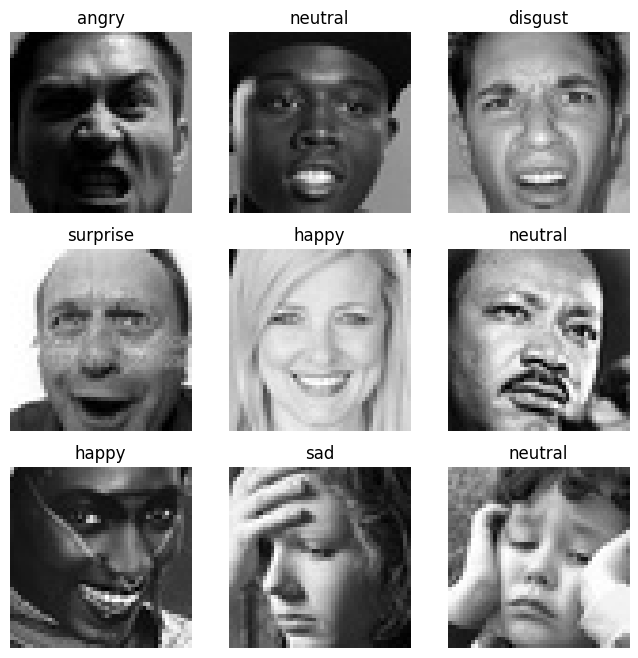

In [ ]:
images, labels = next(train_data)

emotion_names = list(train_data.class_indices.keys())

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].reshape(48,48), cmap='gray')
    plt.title(emotion_names[labels[i].argmax()])
    plt.axis('off')

plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,047 (3.20 MB)

 Trainable params: 839,047 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


898/898 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.3269 - loss: 1.6842 - val_accuracy: 0.4476 - val_loss: 1.4368
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.4768 - loss: 1.3721 - val_accuracy: 0.5060 - val_loss: 1.2968
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.5309 - loss: 1.2401 - val_accuracy: 0.5103 - val_loss: 1.2750
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.5817 - loss: 1.1225 - val_accuracy: 0.5251 - val_loss: 1.2572
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.6246 - loss: 1.0237 - val_accuracy: 0.5346 - val_loss: 1.2405
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6635 - loss: 0.9074 - val_accuracy: 0.5401 - val_loss: 1.2601
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.7081 - loss: 0.7989 - val_accuracy: 0.5465 - val_loss: 1.3104
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.7568 - loss: 0.6857 - val_accurac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


(np.float64(-0.5), np.float64(47.5), np.float64(47.5), np.float64(-0.5))

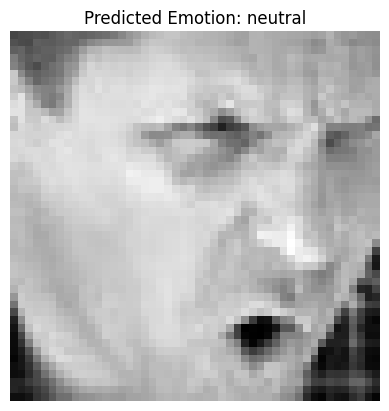

In [ ]:
import numpy as np

img, label = next(test_data)

prediction = model.predict(img[0].reshape(1,48,48,1))
emotion = emotion_names[np.argmax(prediction)]

plt.imshow(img[0].reshape(48,48), cmap='gray')
plt.title("Predicted Emotion: " + emotion)
plt.axis('off')


In [ ]:
#End